# Week 10 Lab 1 — Image Segmentation via Thresholding & Edge Detection

**Dataset:** BSDS (Berkeley Segmentation Dataset) — located in `archive/`

**Tasks:**
1. Load the dataset
2. Create a mask using thresholding
3. Detect edges using gradients
4. Create edge image by thresholding gradient magnitude
5. Show all results together
6. Apply for whole dataset
7. Create a folder to save masks
8. Set one threshold value for the whole dataset
9. Generate masks for all images
10. Show one original image and its mask

## Task 1 — Load the Dataset

In [2]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Paths
DATASET_ROOT = "archive/images"
TRAIN_DIR    = os.path.join(DATASET_ROOT, "train")
TEST_DIR     = os.path.join(DATASET_ROOT, "test")
VAL_DIR      = os.path.join(DATASET_ROOT, "val")

# Collect all image paths across splits
all_image_paths = sorted(
    glob.glob(os.path.join(DATASET_ROOT, "**", "*.jpg"), recursive=True)
)

print(f"Total images found : {len(all_image_paths)}")
print(f"  Train : {len(glob.glob(os.path.join(TRAIN_DIR, '*.jpg')))}")
print(f"  Test  : {len(glob.glob(os.path.join(TEST_DIR,  '*.jpg')))}")
print(f"  Val   : {len(glob.glob(os.path.join(VAL_DIR,   '*.jpg')))}")

# Preview one sample
sample_path = all_image_paths[0]
sample_img  = cv2.imread(sample_path)
sample_img  = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
print(f"\nSample image : {sample_path}")
print(f"Shape        : {sample_img.shape}")

Total images found : 500
  Train : 200
  Test  : 200
  Val   : 100

Sample image : archive/images/test/100007.jpg
Shape        : (321, 481, 3)


## Task 2 — Create a Mask Using Thresholding

In [3]:
def create_threshold_mask(image_bgr, threshold=127):
    """
    Convert image to grayscale and apply binary thresholding.
    Pixels above `threshold` → 255 (foreground), others → 0 (background).
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    return gray, mask

# Demo on sample image
sample_bgr = cv2.imread(sample_path)
gray, mask = create_threshold_mask(sample_bgr, threshold=127)

print("Threshold mask created.")
print(f"  Foreground pixels : {np.sum(mask == 255)}")
print(f"  Background pixels : {np.sum(mask == 0)}")

Threshold mask created.
  Foreground pixels : 124605
  Background pixels : 29796


## Task 3 — Detect Edges Using Gradients

In [4]:
def compute_gradients(gray):
    """
    Compute Sobel gradients Gx and Gy, then the gradient magnitude.
    Returns Gx, Gy, and magnitude (float32).
    """
    Gx  = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)  # horizontal gradient
    Gy  = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)  # vertical gradient
    mag = cv2.magnitude(Gx, Gy)                         # gradient magnitude
    return Gx, Gy, mag

Gx, Gy, mag = compute_gradients(gray)

print("Gradient computation done.")
print(f"  Gx  range : [{Gx.min():.1f}, {Gx.max():.1f}]")
print(f"  Gy  range : [{Gy.min():.1f}, {Gy.max():.1f}]")
print(f"  Mag range : [{mag.min():.1f}, {mag.max():.1f}]")

Gradient computation done.
  Gx  range : [-552.0, 525.0]
  Gy  range : [-565.0, 558.0]
  Mag range : [0.0, 569.7]


## Task 4 — Create Edge Image by Thresholding Gradient Magnitude

In [5]:
def create_edge_image(mag, edge_threshold=50):
    """
    Normalise gradient magnitude to [0,255] then apply binary threshold
    to produce a binary edge map.
    """
    mag_norm = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, edge_img = cv2.threshold(mag_norm, edge_threshold, 255, cv2.THRESH_BINARY)
    return mag_norm, edge_img

EDGE_THRESHOLD = 50
mag_norm, edge_img = create_edge_image(mag, edge_threshold=EDGE_THRESHOLD)

print(f"Edge image created  (threshold = {EDGE_THRESHOLD}).")
print(f"  Edge pixels       : {np.sum(edge_img == 255)}")

Edge image created  (threshold = 50).
  Edge pixels       : 15713


## Task 5 — Show All Results Together

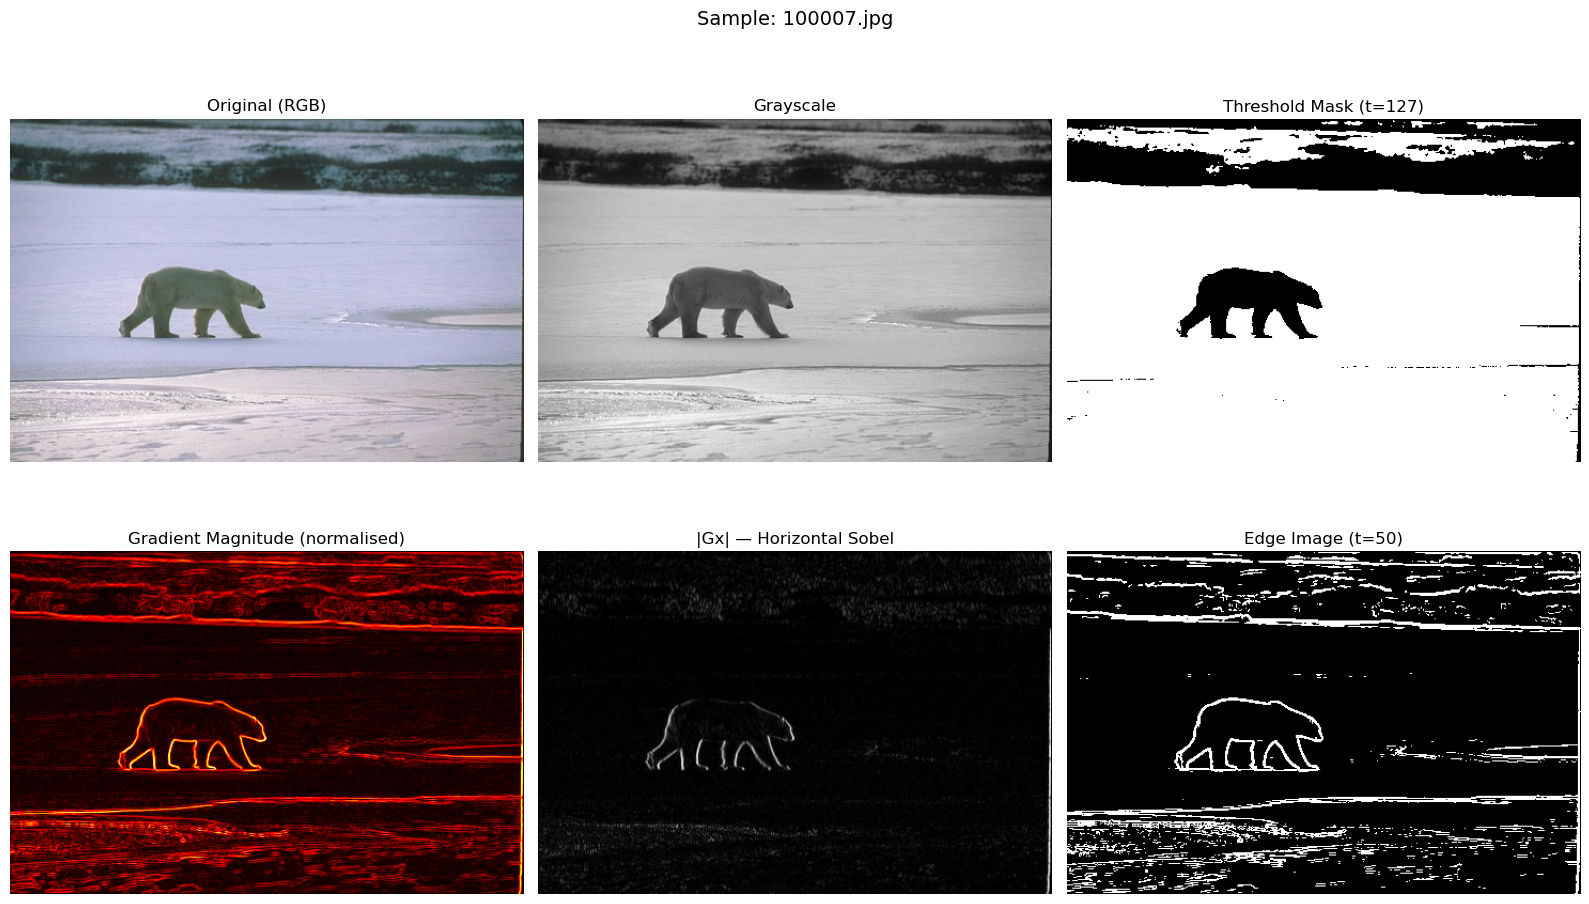

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f"Sample: {os.path.basename(sample_path)}", fontsize=14)

axes[0, 0].imshow(sample_img)
axes[0, 0].set_title("Original (RGB)")

axes[0, 1].imshow(gray, cmap="gray")
axes[0, 1].set_title("Grayscale")

axes[0, 2].imshow(mask, cmap="gray")
axes[0, 2].set_title(f"Threshold Mask (t=127)")

axes[1, 0].imshow(mag_norm, cmap="hot")
axes[1, 0].set_title("Gradient Magnitude (normalised)")

axes[1, 1].imshow(np.abs(Gx), cmap="gray")
axes[1, 1].set_title("|Gx| — Horizontal Sobel")

axes[1, 2].imshow(edge_img, cmap="gray")
axes[1, 2].set_title(f"Edge Image (t={EDGE_THRESHOLD})")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Tasks 6–9 — Apply to Whole Dataset

- **Task 7**: Create `masks/` folder
- **Task 8**: One global threshold for all images (`GLOBAL_THRESHOLD = 127`)
- **Task 9**: Generate and save masks for all images

In [7]:
# Task 7 — Create folder to save masks
MASKS_DIR = "masks"
os.makedirs(MASKS_DIR, exist_ok=True)
print(f"Masks folder: '{MASKS_DIR}' (created / already exists)")

# Task 8 — Single global threshold value
GLOBAL_THRESHOLD = 127
print(f"Global threshold   : {GLOBAL_THRESHOLD}")

Masks folder: 'masks' (created / already exists)
Global threshold   : 127


In [8]:
# Task 9 — Generate masks for all images
def process_image(img_path, threshold, masks_dir):
    """
    Load image → grayscale → threshold mask → save mask.
    Returns the mask.
    """
    bgr  = cv2.imread(img_path)
    if bgr is None:
        return None
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)

    # Preserve sub-folder structure (train/test/val)
    split = os.path.basename(os.path.dirname(img_path))   # e.g. "train"
    out_dir = os.path.join(masks_dir, split)
    os.makedirs(out_dir, exist_ok=True)

    stem     = os.path.splitext(os.path.basename(img_path))[0]
    out_path = os.path.join(out_dir, stem + "_mask.png")
    cv2.imwrite(out_path, mask)
    return mask

# Run on every image
failed = 0
for i, path in enumerate(all_image_paths):
    result = process_image(path, GLOBAL_THRESHOLD, MASKS_DIR)
    if result is None:
        failed += 1
    if (i + 1) % 100 == 0 or (i + 1) == len(all_image_paths):
        print(f"  Processed {i + 1}/{len(all_image_paths)} images …")

print(f"\nDone. Masks saved to '{MASKS_DIR}/' ({len(all_image_paths) - failed} ok, {failed} failed).")

  Processed 100/500 images …
  Processed 200/500 images …
  Processed 300/500 images …
  Processed 400/500 images …
  Processed 500/500 images …

Done. Masks saved to 'masks/' (500 ok, 0 failed).


## Task 10 — Show One Original Image and Its Mask

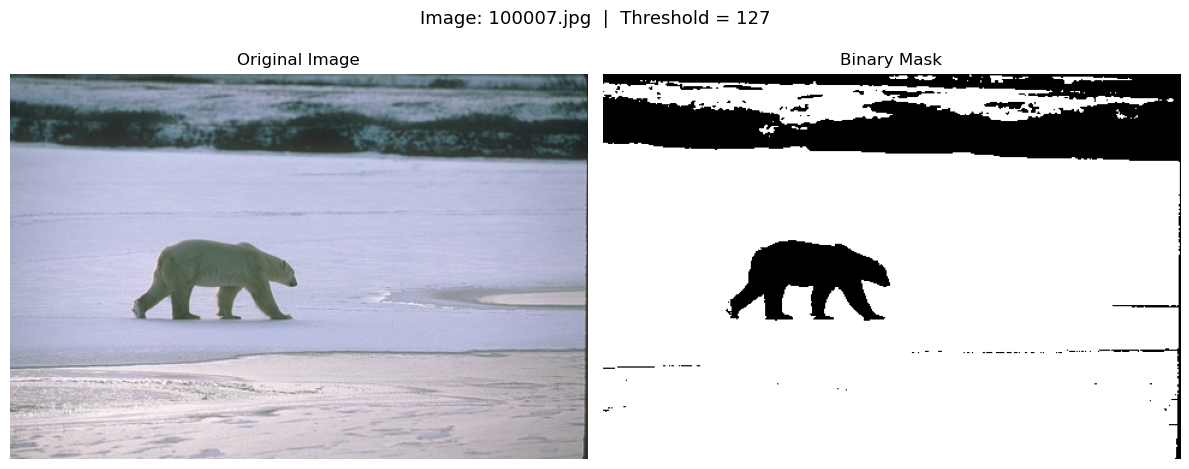

Original : archive/images/test/100007.jpg
Mask     : masks/test/100007_mask.png


In [9]:
# Pick the first test image for a clean demonstration
demo_path = sorted(glob.glob(os.path.join(TEST_DIR, "*.jpg")))[0]
demo_bgr  = cv2.imread(demo_path)
demo_rgb  = cv2.cvtColor(demo_bgr, cv2.COLOR_BGR2RGB)

stem      = os.path.splitext(os.path.basename(demo_path))[0]
mask_path = os.path.join(MASKS_DIR, "test", stem + "_mask.png")
demo_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Image: {stem}.jpg  |  Threshold = {GLOBAL_THRESHOLD}", fontsize=13)

ax1.imshow(demo_rgb)
ax1.set_title("Original Image")
ax1.axis("off")

ax2.imshow(demo_mask, cmap="gray")
ax2.set_title("Binary Mask")
ax2.axis("off")

plt.tight_layout()
plt.show()

print(f"Original : {demo_path}")
print(f"Mask     : {mask_path}")